# Turn motion trace — 90° / 180° / 360° as MOVE segments (binary plane)

Command three **pure in-place turns** — 90°, 180°, 360° CCW — and chart each
one's **heading**, **wheel speed**, and **wheel position** vs time. Every turn
is sent as **one binary `MOVE` segment** (`distance=0`, `direction=0`,
`final_heading=angle`) over the protocol-v3 binary command plane — *not* the
legacy `D`/`T`/`RT` text verbs, which the firmware no longer has (sprint 097
gutted the text channel down to HELP/HELLO/PING/ID/VER/STOP).

**Where the turn should end** is drawn as a horizontal marker on the heading
panel at the commanded angle. The gap between that marker and where the trace
actually lands is the **terminal over/under-rotation** of the segment
executor's pivot stop — the bug tracked in
`clasi/issues/segment-executor-stop-decel-drain-overshoot-reverses.md`.

**Plan vs tracking — the discriminator.** The heading panel carries three
traces: **commanded ∫** (the time-integral of the executor's own commanded
wheel differential, `cmd=`/`bb.drivetrain.vel()` — what the Ruckig plan is
asking for), **encoder** (what the wheels did), and **ground truth** (sim
only). The sim plant has no inertia, so if the *commanded* trace itself misses
the target line, the plan is wrong — Ruckig is being pointed at the wrong
place — and no amount of PID tuning can fix it. If commanded lands on target
and encoder doesn't, the fault is tracking. The speed panel shows the same
split per wheel: measured (solid) vs commanded setpoint (dashed).

## Transport

`TRANSPORT = "sim"` drives the firmware **simulator** in-process
(deterministic, no hardware) with tovez-no-cal geometry and every noise/scrub
knob neutral — and adds a **ground-truth heading** trace from the plant.
`TRANSPORT = "bench"` drives the **real robot** on the stand over USB
(`SerialConnection`, binary plane); heading there is encoder-derived only (no
ground truth). Both paths use the identical command + telemetry code.

**Robot on the stand, wheels off the ground** — safe to spin freely
(`.claude/rules/hardware-bench-testing.md`).

## How it works

Heading is **derived from the wheels**: for a differential drive a pure turn
gives `heading = (pos_right − pos_left) / trackwidth` [rad]. Binary telemetry
(`ReplyEnvelope{tlm}`, auto-pushed every loop pass, `enc`/`vel`/`active`) is
drained continuously; `active` (`bb.drivetrain.busy`) drops when the segment
finishes its graceful decel-to-zero. Sampling continues `SETTLE_S` past that
edge to catch any terminal coast/creep.

## Running it

1. **sim**: just run all cells — no hardware, no port. The capture cell
   **rebuilds the sim lib** (`just build-sim`) and then **verifies
   provenance**: it sends a binary `VER` and hard-stops if the loaded
   firmware version ≠ the workspace version. That mismatch means this
   kernel loaded the dylib before a rebuild (ctypes cannot reload a dylib
   in-process) — **restart the kernel** and re-run.
2. **bench**: robot on the stand, powered, USB connected; **close any serial
   monitor on the port** (the notebook needs exclusive access); set
   `TRANSPORT = "bench"` and confirm `PORT`.
3. Each run caches to `out/turn_trace_<deg>.csv`. The teardown sends a binary
   `STOP` in a `finally` block — motors are never left running (and every
   segment self-terminates anyway).


In [1]:
import math
import pathlib
import sys
import time

import numpy as np
import pandas as pd

# --- Paths: anchored to the repo, never CWD-relative. ---
_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "host" / "robot_radio").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")
sys.path.insert(0, str(REPO / "host"))

OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Session configuration -------------------------------------------------
TRANSPORT = "sim"                  # "sim" (deterministic + ground truth) | "bench"
PORT = "/dev/cu.usbmodem2121102"   # bench robot (direct USB); check `ls /dev/cu.usbmodem*`
MODE = "direct"
TRACKWIDTH = 128.0                 # [mm] data/robots/tovez_nocal.json geometry.trackwidth
STEP = 20                          # [ms] sim tick / bench poll cadence
STREAM_PERIOD = 20                 # [ms] sim binary-telemetry arm (proto floor)
SETTLE_S = 1.0                     # [s] keep sampling this long past active=0
STEP_TIMEOUT_S = 15.0              # [s] per-turn ceiling before "hung"
SPINUP_TICKS = 6                   # grace ticks before an idle frame is trusted
FORCE_RECAPTURE = True             # True re-drives even if cached

# Three pure in-place turns, CCW (+). Each is sent as ONE binary MOVE segment
# (distance=0, direction=0, final_heading=angle) via segment_for_rt() -- the
# legacy RT verb's binary form, NOT a text command.
TURNS = [90.0, 180.0, 360.0]       # [deg]

print(f"repo:      {REPO}")
print(f"cache:     {OUT_DIR}")
print(f"transport: {TRANSPORT}" + (f"  port={PORT} ({MODE})" if TRANSPORT == "bench" else ""))
print(f"turns:     {TURNS}  (each a MOVE segment, trackwidth={TRACKWIDTH:.0f}mm)")


repo:      /Volumes/Proj/proj/RobotProjects/radio-robot-elite
cache:     /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/notebooks/out
transport: sim
turns:     [90.0, 180.0, 360.0]  (each a MOVE segment, trackwidth=128mm)


In [2]:
# --- Command + capture: one MOVE segment per turn, drain binary TLM --------
# turn_envelope() builds the SAME MotionSegment the firmware executes for a
# MOVE: distance=0, direction=0, final_heading=angle (a pure in-place pivot,
# the whole rotation in the executor's TERMINAL_PIVOT phase). Heading is
# derived from the wheels -- (pos_r - pos_l)/trackwidth -- so it needs no pose
# estimator (fused `pose` is still 0 pre-098; encpose is trimmed off binary
# TLM to fit the 186B envelope budget). The sim path additionally samples the
# plant's ground-truth heading each tick.
from robot_radio.robot import legacy_translate
from robot_radio.robot.pb2 import envelope_pb2
from robot_radio.robot.protocol import TLMFrame


def turn_envelope(angle):  # [deg]
    """One pure in-place turn as a binary MOVE segment (`segment` arm)."""
    seg = legacy_translate.segment_for_rt(angle * 100.0)   # [cdeg] -> rad inside
    return envelope_pb2.CommandEnvelope(segment=seg)


def stop_envelope():
    env = envelope_pb2.CommandEnvelope()
    env.stop.SetInParent()
    return env


def _row(fr, base, t):
    """One telemetry frame -> a plot row (position baselined, heading derived).
    cmd_l/cmd_r is the COMMANDED per-wheel velocity -- the velocity PID's own
    setpoint (bb.drivetrain.vel(), TLM cmd=), i.e. what the segment executor's
    Ruckig plan is asking for THIS instant, before any tracking error."""
    pos_l = fr.enc[0] - base[0]      # [mm]
    pos_r = fr.enc[1] - base[1]      # [mm]
    vel = fr.vel if fr.vel else (0, 0)
    cmd = fr.cmd_vel if fr.cmd_vel else (0, 0)
    return {"t": t, "pos_l": pos_l, "pos_r": pos_r,
            "vel_l": vel[0], "vel_r": vel[1],
            "cmd_l": cmd[0], "cmd_r": cmd[1],
            "heading_enc": math.degrees((pos_r - pos_l) / TRACKWIDTH),
            "active": int(fr.active)}


def _finalize(rows):
    """df + done_t, where done_t is the firmware's OWN segment-complete
    signal: the `active` (bb.drivetrain.busy) flag's 1->0 edge -- the first
    idle frame after the busy period. This is the objective moment the
    executor declares the turn finished, and the instant a chained tour fires
    its next leg (so it is the heading each subsequent leg inherits). It sits
    a terminal-dwell AFTER the wheels physically stop (see settle_t below)."""
    df = pd.DataFrame(rows)
    done_t = None
    if not df.empty and (df["active"] == 1).to_numpy().any():
        busy = df["active"].to_numpy() == 1
        last_busy = int(np.where(busy)[0][-1])
        # the 1->0 edge: first idle frame after the last busy one (fall back to
        # the last busy instant if the run ended while still busy).
        idx = last_busy + 1 if last_busy + 1 < len(df) else last_busy
        done_t = float(df["t"].iloc[idx])
    return df, done_t


def settle_t(df):
    """Physical end of motion: after the speed peak, the first frame where
    both wheels drop below kSettleSpeed. Marked lighter than done_t so the
    terminal-dwell gap (settle_t -> done_t) reads as dwell, not slow motion."""
    if df is None or df.empty:
        return None
    kSettleSpeed = 3.0  # [mm/s]
    speed = df[["vel_l", "vel_r"]].abs().max(axis=1).to_numpy()
    peak_i = int(np.argmax(speed))
    stopped = np.where((speed < kSettleSpeed) & (np.arange(len(df)) > peak_i))[0]
    return float(df["t"].iloc[int(stopped[0])]) if len(stopped) else None


def heading_cmd(df):
    """COMMANDED heading: the time-integral of the commanded differential,
    (cmd_r - cmd_l)/trackwidth, trapezoid rule over the frame times. This is
    what the segment executor's own plan adds up to -- the discriminator
    between "the plan is wrong" (this lands off-target) and "the tracking is
    wrong" (this lands on-target but the encoder heading doesn't)."""
    if df is None or df.empty or "cmd_l" not in df.columns:
        return None
    omega = (df["cmd_r"] - df["cmd_l"]).to_numpy() / TRACKWIDTH   # [rad/s]
    t = df["t"].to_numpy()
    h = np.zeros(len(df))
    h[1:] = np.cumsum(0.5 * (omega[1:] + omega[:-1]) * np.diff(t))
    return np.degrees(h)


def capture_sim(conn, proto, angle):
    """Drive one turn in the sim; tick + drain until active=0 (+ SETTLE_S).
    Adds a ground-truth heading column (unwrapped past +/-180)."""
    from robot_radio.testgui import binary_bridge
    conn.set_true_pose(0.0, 0.0, 0.0)                          # fresh start
    binary_bridge.translate_command(proto, f"STREAM {STREAM_PERIOD}")
    conn.drain_binary_tlm()
    reply = conn.send_envelope(turn_envelope(angle))
    body = reply.WhichOneof("body") if reply is not None else None
    if body != "ok":
        raise RuntimeError(f"{angle:.0f}deg segment rejected: body={body}")

    rows, base, t = [], None, 0.0
    prev_h, unwrap = None, 0
    last_active, idle_at = None, None
    settle = int(SETTLE_S * 1000 / STEP)
    for i in range(int(STEP_TIMEOUT_S * 1000 / STEP)):
        conn.tick(STEP)
        t += STEP / 1000.0
        for f in conn.drain_binary_tlm():
            fr = TLMFrame.from_pb2(f.tlm)
            if fr.enc is None:
                continue
            if base is None:
                base = fr.enc
            r = _row(fr, base, t)
            h = conn.get_true_pose()["h"]                      # [rad], (-pi, pi]
            if prev_h is not None and h - prev_h < -math.pi:
                unwrap += 1
            elif prev_h is not None and h - prev_h > math.pi:
                unwrap -= 1
            prev_h = h
            r["heading_true"] = math.degrees(h + 2 * math.pi * unwrap)
            last_active = bool(fr.active)
            rows.append(r)
        if i >= SPINUP_TICKS and last_active is False:
            idle_at = i if idle_at is None else idle_at
            if i - idle_at >= settle:
                break
        else:
            idle_at = None
    conn.send_envelope(stop_envelope())
    return _finalize(rows)


def capture_bench(conn, angle):
    """Drive one turn on the real robot; poll binary TLM in real time until
    active=0 (+ SETTLE_S). No ground truth -- heading is encoder-derived."""
    conn.send_envelope(stop_envelope(), read_timeout=300)
    time.sleep(0.8)                                            # let prior coast settle
    base = None
    for f in conn.read_binary_tlm(600):                       # encoder baseline
        fr = TLMFrame.from_pb2(f.tlm)
        if fr.enc is not None:
            base = fr.enc
    conn.drain_binary_tlm()

    reply = conn.send_envelope(turn_envelope(angle), read_timeout=500)
    rep = (reply or {}).get("reply")
    if rep is None or rep.WhichOneof("body") != "ok":
        raise RuntimeError(f"{angle:.0f}deg segment rejected: {reply}")

    rows, t0 = [], time.monotonic()
    last_active, idle_since, seen = None, None, False
    while time.monotonic() - t0 < STEP_TIMEOUT_S:
        for f in conn.drain_binary_tlm():
            fr = TLMFrame.from_pb2(f.tlm)
            if fr.enc is None:
                continue
            if base is None:
                base = fr.enc
            r = _row(fr, base, time.monotonic() - t0)
            r["heading_true"] = float("nan")
            last_active = bool(fr.active)
            if last_active:
                seen = True
            rows.append(r)
        if seen and last_active is False:
            idle_since = idle_since or time.monotonic()
            if time.monotonic() - idle_since >= SETTLE_S:
                break
        else:
            idle_since = None
        time.sleep(STEP / 1000.0)
    conn.send_envelope(stop_envelope(), read_timeout=300)
    return _finalize(rows)


In [3]:
# --- Drive the robot (once) and cache each turn ----------------------------
# Safe teardown: STOP in the finally block, so a mid-run exception or Ctrl-C
# never leaves motors live (every segment self-terminates anyway).

def _load_cached(angle):
    df = pd.read_csv(OUT_DIR / f"turn_trace_{int(angle)}.csv")
    dt = df["done_t"].iloc[0] if "done_t" in df.columns and len(df) else None
    return df, (None if dt is None or pd.isna(dt) else float(dt))


captures = {}
need = FORCE_RECAPTURE or any(
    not (OUT_DIR / f"turn_trace_{int(a)}.csv").exists() for a in TURNS)

if not need:
    print("all turns cached -- skipping hardware (FORCE_RECAPTURE=True to re-drive)")
    for a in TURNS:
        captures[a] = _load_cached(a)
        print(f"  cached: turn_trace_{int(a)}.csv ({len(captures[a][0])} frames)")

elif TRANSPORT == "sim":
    import subprocess

    from robot_radio.io.sim_conn import SimConnection
    from robot_radio.robot.protocol import NezhaProtocol
    from robot_radio.testgui import sim_prefs

    # --- Sim provenance: rebuild, then PROVE the loaded firmware is current.
    # `just build-sim` is fast on an unchanged tree. The trap it cannot fix:
    # ctypes caches a loaded dylib per process, so a LONG-LIVED kernel that
    # connected before a rebuild keeps executing the OLD firmware no matter
    # what is on disk -- results then silently reflect stale code. The VER
    # handshake below catches exactly that: the version is baked into the
    # dylib at build time (scripts/gen_version.py, run by build-sim), so a
    # mismatch against the workspace's pyproject version means THIS PROCESS
    # holds a stale sim -- restart the kernel.
    print("rebuilding sim lib (just build-sim)...")
    _res = subprocess.run(["just", "build-sim"], cwd=REPO, capture_output=True, text=True)
    if _res.returncode != 0:
        raise RuntimeError(f"just build-sim failed:\n{_res.stderr[-2000:]}")
    import tomllib
    with open(REPO / "pyproject.toml", "rb") as _f:
        WORKSPACE_VERSION = tomllib.load(_f)["project"]["version"]

    def check_sim_provenance(conn):
        """Send binary VER; hard-stop on a stale in-process dylib."""
        env = envelope_pb2.CommandEnvelope()
        env.ver.SetInParent()
        reply = conn.send_envelope(env)
        fw = reply.id.fw_version if reply is not None and reply.WhichOneof("body") == "id" else "?"
        print(f"sim firmware: v{fw}   workspace: v{WORKSPACE_VERSION}")
        if fw != WORKSPACE_VERSION:
            raise RuntimeError(
                f"STALE SIM: this kernel holds firmware v{fw} but the workspace is "
                f"v{WORKSPACE_VERSION}. ctypes cannot reload a dylib in-process -- "
                "RESTART THE KERNEL and re-run."
            )

    def _apply_zero_error(conn):
        """tovez-no-cal geometry, every noise/scrub knob neutral -- same
        profile->setter mapping transport.py's _apply_profile_to_sim() uses."""
        profile = dict(sim_prefs.DEFAULT_PROFILE)
        profile["trackwidth"] = TRACKWIDTH
        for key, setter in sim_prefs.PROFILE_TO_SIM_SETTER.items():
            getattr(conn, setter)(profile[key])
        conn.set_enc_noise(2, profile["encoder_noise"])
        conn.set_enc_scale_error(0, profile["enc_scale_err_l"])
        conn.set_enc_scale_error(1, profile["enc_scale_err_r"])

    conn = SimConnection(tick_step=STEP)
    assert "error" not in conn.connect(), "sim connect failed"
    check_sim_provenance(conn)
    _apply_zero_error(conn)
    proto = NezhaProtocol(conn)
    try:
        for a in TURNS:
            df, done = capture_sim(conn, proto, a)
            out = df.copy(); out["done_t"] = done
            out.to_csv(OUT_DIR / f"turn_trace_{int(a)}.csv", index=False)
            captures[a] = (df, done)
            fin = df["heading_true"].iloc[-1] if len(df) else float("nan")
            print(f"  {a:6.0f}deg: {len(df):3d} frames  done_t={done}"
                  f"  final(truth)={fin:7.2f}deg  overshoot={fin - a:+.2f}deg")
    finally:
        try:
            conn.send_envelope(stop_envelope())
        finally:
            conn.disconnect()
            print("[safety] STOP sent; sim closed")

else:  # bench
    from robot_radio.io.serial_conn import SerialConnection

    conn = SerialConnection(port=PORT, mode=MODE)
    try:
        info = conn.connect(skip_ping=False)
        if not conn.is_open:
            raise RuntimeError(f"connect failed -- serial monitor holding the port? {info}")
        print(f"connected: {info.get('status')}  {PORT}")
        for a in TURNS:
            print(f"\n=== {a:.0f}deg turn (MOVE segment) ===")
            df, done = capture_bench(conn, a)
            out = df.copy(); out["done_t"] = done
            out.to_csv(OUT_DIR / f"turn_trace_{int(a)}.csv", index=False)
            captures[a] = (df, done)
            fin = df["heading_enc"].iloc[-1] if len(df) else float("nan")
            print(f"  {len(df)} frames  done_t={done}  final(enc)={fin:.2f}deg"
                  f"  overshoot={fin - a:+.2f}deg")
    finally:
        try:
            conn.send_envelope(stop_envelope(), read_timeout=300)
        except Exception as exc:                              # noqa: BLE001
            print(f"  WARN STOP on teardown: {exc}")
        if conn.is_open:
            conn.disconnect()
            print("\n[safety] STOP sent; serial closed")


rebuilding sim lib (just build-sim)...


sim firmware: v0.20260711.2   workspace: v0.20260711.2
      90deg:  93 frames  done_t=0.8600000000000004  final(truth)=  89.74deg  overshoot=-0.26deg
     180deg: 102 frames  done_t=1.0400000000000005  final(truth)= 179.91deg  overshoot=-0.09deg
     360deg: 128 frames  done_t=1.560000000000001  final(truth)= 360.18deg  overshoot=+0.18deg
[safety] STOP sent; sim closed


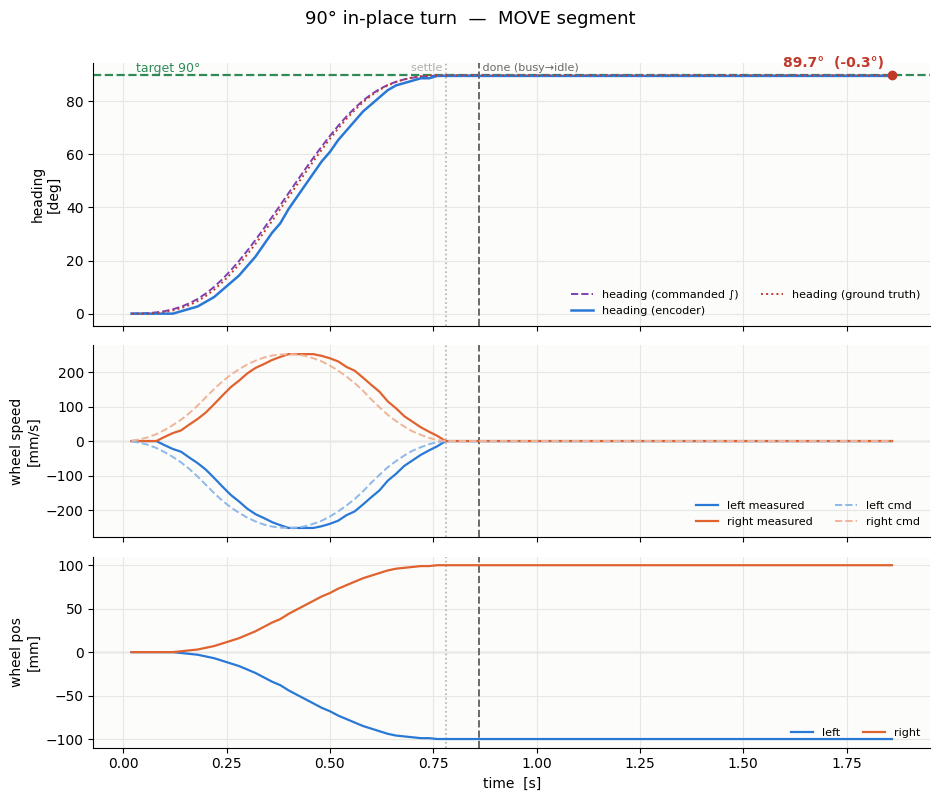

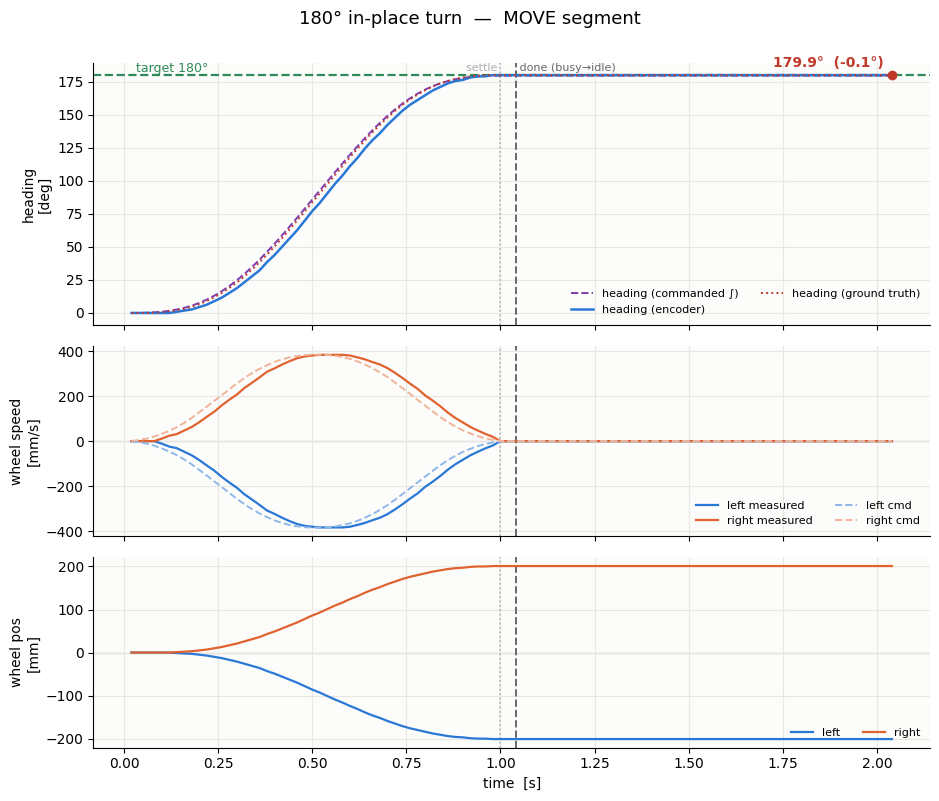

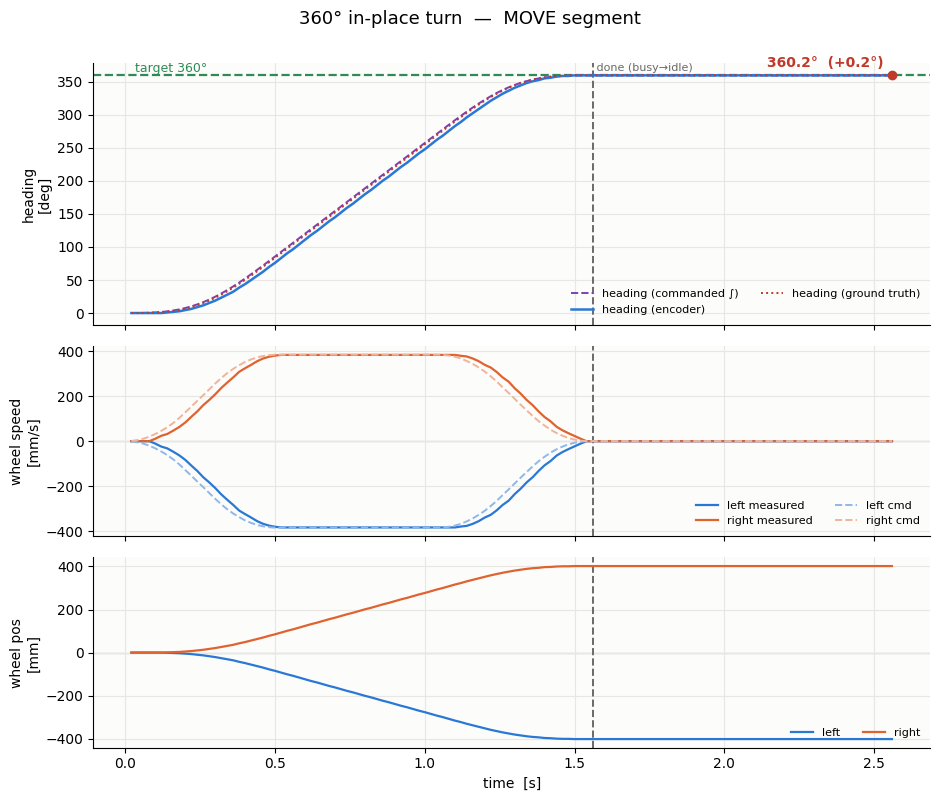

In [4]:
# --- Chart: heading (vs commanded target) / wheel speed / wheel position ---
# One figure per turn. The heading panel draws a horizontal marker at the
# COMMANDED angle -- "where the turn should end" -- plus two vertical markers:
#   done   (solid grey) -- the firmware's active/busy flag 1->0 edge: the
#          executor's own segment-complete signal, where a chained tour fires
#          its next leg. This is where the turn's result is committed.
#   settle (dotted grey) -- physical end of motion (wheels stopped). The gap
#          done - settle is the executor's terminal dwell (busy held after the
#          wheels stop). The over/under-rotation is the gap between the trace's
#          resting value and the target line, read at `done`.
import matplotlib.pyplot as plt

ENC = "#2a78d6"      # encoder-derived heading / left wheel
TRUTH = "#c0392b"    # ground-truth heading (sim)
RIGHT = "#e0632f"    # right wheel
CMD_H = "#7d3fb3"    # commanded-heading integral (the executor's own plan)
CMD_L = "#8fb8e8"    # left commanded velocity (lighter, dashed)
CMD_R = "#f0b499"    # right commanded velocity (lighter, dashed)
TARGET = "#2e8b57"   # commanded-angle marker ("should end")
DONE = "#6a6a6a"     # busy->idle completion marker
SETTLE = "#b0b0b0"   # physical-settle marker


def plot_turn(angle, df, done_t):
    if df is None or df.empty:
        print(f"{angle:.0f}deg: no data")
        return
    # Only surface the physical-settle marker when the executor holds `busy`
    # a visible dwell past the wheels stopping (>40ms). For a simple turn the
    # busy flag clears the instant the wheels stop, so settle == done and a
    # second line would only clutter; the 360deg reversal tail is where they
    # separate.
    _s = settle_t(df)
    settle = _s if (_s is not None and done_t is not None
                    and done_t - _s > 0.04) else None
    fig, (ax_h, ax_v, ax_p) = plt.subplots(
        3, 1, figsize=(9.5, 8), sharex=True, facecolor="white",
        gridspec_kw={"height_ratios": [2.2, 1.6, 1.6]})
    fig.suptitle(f"{angle:.0f}° in-place turn  —  MOVE segment", fontsize=13, y=0.995)
    for ax in (ax_h, ax_v, ax_p):
        ax.set_facecolor("#fcfcfb")
        ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        if settle is not None:
            ax.axvline(settle, color=SETTLE, ls=":", lw=1.2, zorder=2)
        if done_t is not None:
            ax.axvline(done_t, color=DONE, ls="--", lw=1.4, zorder=2)

    # 1. heading: commanded plan + encoder-derived + ground truth, vs target.
    #    heading (commanded) is the integral of the executor's OWN setpoint --
    #    if IT misses the target line, the plan is wrong, not the tracking.
    ax_h.axhline(angle, color=TARGET, ls="--", lw=1.6, zorder=2)
    ax_h.text(df["t"].iloc[0], angle, f" target {angle:.0f}°",
              color=TARGET, fontsize=9, va="bottom")
    h_cmd = heading_cmd(df)
    if h_cmd is not None:
        ax_h.plot(df["t"], h_cmd, color=CMD_H, lw=1.4, ls="--",
                  label="heading (commanded ∫)")
    ax_h.plot(df["t"], df["heading_enc"], color=ENC, lw=1.8, label="heading (encoder)")
    if "heading_true" in df.columns and df["heading_true"].notna().any():
        ax_h.plot(df["t"], df["heading_true"], color=TRUTH, lw=1.4, ls=":",
                  label="heading (ground truth)")
    fin = (df["heading_true"] if "heading_true" in df.columns
           and df["heading_true"].notna().any() else df["heading_enc"]).iloc[-1]
    ax_h.plot(df["t"].iloc[-1], fin, "o", color=TRUTH, ms=6, zorder=4)
    ax_h.annotate(f"{fin:.1f}°  ({fin - angle:+.1f}°)",
                  (df["t"].iloc[-1], fin), textcoords="offset points",
                  xytext=(-6, 6), ha="right", color=TRUTH, fontsize=10, fontweight="bold")
    ax_h.set_ylabel("heading\n[deg]")

    # 2. wheel speed: measured (solid) vs commanded PID setpoint (dashed)
    ax_v.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    ax_v.plot(df["t"], df["vel_l"], color=ENC, lw=1.6, label="left measured")
    ax_v.plot(df["t"], df["vel_r"], color=RIGHT, lw=1.6, label="right measured")
    if "cmd_l" in df.columns:
        ax_v.plot(df["t"], df["cmd_l"], color=CMD_L, lw=1.4, ls="--", label="left cmd")
        ax_v.plot(df["t"], df["cmd_r"], color=CMD_R, lw=1.4, ls="--", label="right cmd")
    ax_v.set_ylabel("wheel speed\n[mm/s]")

    # 3. wheel position (opposite signs for a pure turn)
    ax_p.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    ax_p.plot(df["t"], df["pos_l"], color=ENC, lw=1.6, label="left")
    ax_p.plot(df["t"], df["pos_r"], color=RIGHT, lw=1.6, label="right")
    ax_p.set_ylabel("wheel pos\n[mm]")
    ax_p.set_xlabel("time  [s]")

    for ax in (ax_h, ax_v, ax_p):
        ax.legend(loc="lower right", frameon=False, fontsize=8, ncol=2)
    top = ax_h.get_ylim()[1]
    if settle is not None:
        ax_h.text(settle, top, "settle ", color=SETTLE, fontsize=8, va="top", ha="right")
    if done_t is not None:
        ax_h.text(done_t, top, " done (busy→idle)", color=DONE, fontsize=8, va="top")
    fig.tight_layout()
    plt.show()


for a in TURNS:
    df, done = captures.get(a, (None, None))
    plot_turn(a, df, done)


In [5]:
# --- Summary: plan vs tracking vs target, over-rotation, terminal creep ----
# cmd_final_deg  = where the executor's OWN commanded plan integrates to.
# final_deg      = where the robot actually rests (truth in sim, encoder on
#                  the bench). cmd_final ~= final => tracking is faithful and
#                  any miss vs turn_deg is the PLAN's, not the PID's.
# overshoot      = final - commanded angle (+ = over-rotation).
# terminal_creep = furthest the heading moves AFTER the completion edge.

def summarize(angle, df, done_t):
    if df is None or df.empty:
        return {"turn_deg": angle, "frames": 0}
    col = ("heading_true" if "heading_true" in df.columns
           and df["heading_true"].notna().any() else "heading_enc")
    final = float(df[col].iloc[-1])
    out = {"turn_deg": angle, "frames": len(df),
           "final_deg": round(final, 2),
           "overshoot_deg": round(final - angle, 2),
           "overshoot_pct": round(100.0 * (final - angle) / angle, 1),
           "peak_speed": round(float(df[["vel_l", "vel_r"]].abs().to_numpy().max()), 1)}
    h_cmd = heading_cmd(df)
    if h_cmd is not None:
        out["cmd_final_deg"] = round(float(h_cmd[-1]), 2)
    st = settle_t(df)                                    # physical stop
    if st is not None and done_t is not None:
        out["dwell_s"] = round(done_t - st, 3)           # busy held past stop
    if done_t is not None:
        post = df[df["t"] >= done_t][col]
        if len(post) > 1:
            out["terminal_creep_deg"] = round(float(post.max() - post.min()), 2)
    return out


pd.DataFrame([summarize(a, *captures.get(a, (None, None))) for a in TURNS])


,turn_deg,frames,final_deg,overshoot_deg,overshoot_pct,peak_speed,cmd_final_deg,dwell_s,terminal_creep_deg
0,90.0,93,89.74,-0.26,-0.3,252.0,89.62,0.08,0.0
1,180.0,102,179.91,-0.09,-0.1,383.0,179.58,0.04,0.0
2,360.0,128,360.18,0.18,0.0,383.0,359.65,0.02,0.0
